# Projeto - Robô seguido de parede

**Objetivo:** criar uma rede MLP que consiga classificar corretamente qual é a ação que deve ser tomada para que o robô permanece seguindo uma parede.


**Proposta futura:** Criar uma rede MLP para obter a função de custo para que o robô possa se mover de maneira autônoma em um ambiente.

## Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping

I0000 00:00:1788440807.771753   43378 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788440808.015265   43378 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Data extract

In [2]:
# Carrega os dados do repositório
url = url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00194/sensor_readings_24.data"

df = pd.read_csv(url)

In [3]:
df.head()

,0.438,0.498,3.625,3.645,5.000,2.918,5.000.1,2.351,2.332,2.643,...,0.593,0.502,0.493,0.504,0.445,0.431,0.444,0.440,0.429,Slight-Right-Turn
0,0.438,0.498,3.625,3.648,5.0,2.918,5.0,2.637,2.332,2.649,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.443,0.429,Slight-Right-Turn
1,0.438,0.498,3.625,3.629,5.0,2.918,5.0,2.637,2.334,2.643,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.446,0.429,Slight-Right-Turn
2,0.437,0.501,3.625,3.626,5.0,2.918,5.0,2.353,2.334,2.642,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.444,0.429,Slight-Right-Turn
3,0.438,0.498,3.626,3.629,5.0,2.918,5.0,2.640,2.334,2.639,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.441,0.429,Slight-Right-Turn
4,0.439,0.498,3.626,3.629,5.0,2.918,5.0,2.633,2.334,2.645,...,0.589,0.502,0.493,0.504,0.446,0.431,0.444,0.444,0.430,Slight-Right-Turn


In [4]:
# criando as colunas
col = [f"sensor_{i}" for i in range(1, 25)] + ["acao"]

df = pd.read_csv(url, names=col)

df.head()

,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,sensor_22,sensor_23,sensor_24,acao
0,0.438,0.498,3.625,3.645,5.0,2.918,5.0,2.351,2.332,2.643,...,0.593,0.502,0.493,0.504,0.445,0.431,0.444,0.440,0.429,Slight-Right-Turn
1,0.438,0.498,3.625,3.648,5.0,2.918,5.0,2.637,2.332,2.649,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.443,0.429,Slight-Right-Turn
2,0.438,0.498,3.625,3.629,5.0,2.918,5.0,2.637,2.334,2.643,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.446,0.429,Slight-Right-Turn
3,0.437,0.501,3.625,3.626,5.0,2.918,5.0,2.353,2.334,2.642,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.444,0.429,Slight-Right-Turn
4,0.438,0.498,3.626,3.629,5.0,2.918,5.0,2.640,2.334,2.639,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.441,0.429,Slight-Right-Turn


In [10]:
df.describe()

,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,sensor_22,sensor_23,sensor_24
count,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,...,5456.000000,5456.000000,5456.000000,5456.000000,5456.00000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000
mean,1.471617,2.327043,2.489347,2.796501,2.958552,2.893073,3.351113,2.540397,3.125621,2.832386,...,2.205772,1.202111,0.989831,0.910273,1.05811,1.076320,1.015923,1.778034,1.555045,1.578508
std,0.802801,1.410146,1.247435,1.309368,1.339225,1.282575,1.413692,1.111554,1.356965,1.307843,...,1.715435,1.098568,0.942075,0.889527,1.14463,1.141498,0.887439,1.571686,1.291447,1.150480
min,0.400000,0.437000,0.470000,0.833000,1.120000,1.114000,1.122000,0.859000,0.836000,0.810000,...,0.495000,0.424000,0.373000,0.354000,0.34000,0.355000,0.380000,0.370000,0.367000,0.377000
25%,0.921000,1.362000,1.538750,1.731000,1.774000,1.785750,1.930750,1.618000,1.799750,1.636000,...,0.860000,0.690000,0.581000,0.529750,0.52300,0.541750,0.567000,0.743000,0.792000,0.884000
50%,1.335000,1.904500,2.064000,2.458000,2.667000,2.682500,3.225500,2.172000,2.802000,2.679000,...,1.328500,0.803000,0.738000,0.685000,0.69100,0.693000,0.764000,1.030500,1.071000,1.289000
75%,1.814000,2.681500,2.739250,4.093500,4.314500,3.835250,5.000000,3.193000,5.000000,3.526250,...,4.436250,1.159000,0.913000,0.837000,0.85700,0.863000,1.002250,2.068250,1.559500,1.657250
max,5.000000,5.025000,5.029000,5.017000,5.000000,5.005000,5.008000,5.087000,5.000000,5.022000,...,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5456 entries, 0 to 5455
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sensor_1   5456 non-null   float64
 1   sensor_2   5456 non-null   float64
 2   sensor_3   5456 non-null   float64
 3   sensor_4   5456 non-null   float64
 4   sensor_5   5456 non-null   float64
 5   sensor_6   5456 non-null   float64
 6   sensor_7   5456 non-null   float64
 7   sensor_8   5456 non-null   float64
 8   sensor_9   5456 non-null   float64
 9   sensor_10  5456 non-null   float64
 10  sensor_11  5456 non-null   float64
 11  sensor_12  5456 non-null   float64
 12  sensor_13  5456 non-null   float64
 13  sensor_14  5456 non-null   float64
 14  sensor_15  5456 non-null   float64
 15  sensor_16  5456 non-null   float64
 16  sensor_17  5456 non-null   float64
 17  sensor_18  5456 non-null   float64
 18  sensor_19  5456 non-null   float64
 19  sensor_20  5456 non-null   float64
 20  sensor_21  5456 non

In [ ]:
# Separa o X e o y bruto
X = df.drop(columns=["acao"])
y_raw = df["acao"].values

Outra forma de ingestão de dados:

```python
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
wine_quality = fetch_ucirepo(id=186) 
  
# data (as pandas dataframes) 
X = wine_quality.data.features 
y = wine_quality.data.targets 
  
# metadata 
print(wine_quality.metadata) 
  
# variable information 
print(wine_quality.variables) 
```

In [ ]:
"""
No KNN a divisão entr os vinhos foi feita pelo código:
df["target"] = pd.cut(
df["quality"],
bins=[0, 5, 7, 10],
labels=[0, 1, 2], # - O ruim, 1 - médio, 2 - bom
include_lowest=True
).astype(int)

df.columns
"""

# Mapeamento igual ao KNN (bins=[0, 5, 7, 10])
y = np.where(y <= 5, 0, 
       np.where(y <= 7, 1, 2))

In [ ]:
np.unique(y)

array([0, 1, 2])

In [ ]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
dtypes: float64(11)
memory usage: 137.5 KB


## Data transform

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
test_size=0.2, random_state=42, stratify=y)
# stratify obriga que o conjunto de Teste tenha exatamente a 
# mesma proporção de vinhos de cada classe que existe no dataset original 
# usado para tentar deixar o mais similar possível ao projeto do KNN

print(f" Total de amostras: {len(X)}")

 Total de amostras: 1599


In [ ]:
normalizer = StandardScaler()
X_train_scaled = normalizer.fit_transform(X_train)
X_test_scaled = normalizer.transform(X_test)

## Data load

In [ ]:
# NDA

## Model

In [ ]:
"""
BatchNormalization(): Ele é uma camada que pega o resultado (a saída) dos neurônios da camada anterior
 e re-normaliza os números (centralizando em torno de zero) antes de passá-los 
 para a próxima camada.
"""

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(11,)), # 11 features

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.BatchNormalization(), 
    
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    
    tf.keras.layers.Dense(32, activation="relu"),
    
    tf.keras.layers.Dense(3, activation="softmax") # "multiclasses"
])

## Train

In [ ]:
# Compile
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
#loss_func = tf.keras.losses.MeanSquaredError()
loss_func = tf.keras.losses.SparseCategoricalCrossentropy()
"""
Se fizer o one-hot manual usar loss_func: categoricalCrossentropy
Se manter com os valores sem modificação usar SparseCategoricalCrossentropy
"""

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=25, 
    restore_best_weights=True
)

model.compile(optimizer=optimizer, loss=loss_func, metrics=["accuracy"]) # adição de métrica para compilar



In [ ]:
# Train'
history = model.fit(
    X_train_scaled, y_train, 
    epochs=200, 
    batch_size=32, 
    validation_split=0.1,
    callbacks=[early_stop], 
    verbose=1
)

Epoch 1/200


I0000 00:00:1788222294.587767  188311 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_320798__.26


25/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4092 - loss: 1.3029

I0000 00:00:1788222295.630817  188311 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_320798__.26


36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.3953 - loss: 1.2190 - val_accuracy: 0.4062 - val_loss: 1.0859
Epoch 2/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5334 - loss: 0.9621 - val_accuracy: 0.4609 - val_loss: 0.9713
Epoch 3/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6255 - loss: 0.8217 - val_accuracy: 0.5312 - val_loss: 0.8876
Epoch 4/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6725 - loss: 0.7492 - val_accuracy: 0.5781 - val_loss: 0.8229
Epoch 5/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7089 - loss: 0.6998 - val_accuracy: 0.6094 - val_loss: 0.7710
Epoch 6/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7272 - loss: 0.6788 - val_accuracy: 0.6641 - val_loss: 0.7253
Epoch 7/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7402 - loss: 0.6480 - val_accuracy: 0.6641 - val_loss: 0.6834
Epoch 8/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7420 - loss: 0.6256 - val_accuracy: 0.7109 - val_loss: 0.

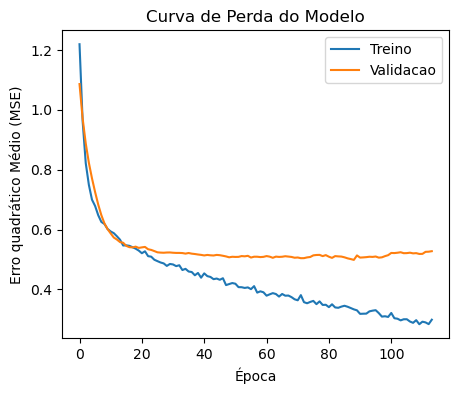

In [ ]:
plt.figure(figsize=(5, 4))
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Curva de Perda do Modelo")
plt.ylabel("Erro quadrático Médio (MSE)")
#plt.yscale("log")
plt.xlabel("Época")
plt.legend(["Treino", "Validacao"])

## Predict

In [ ]:
# Predição
y_pred_prob = model.predict(X_test_scaled)
y_pred_prob

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


array([[2.31633312e-03, 9.81487334e-01, 1.61963571e-02],
       [2.09009990e-01, 7.90356100e-01, 6.33918331e-04],
       [9.98043895e-01, 1.88143016e-03, 7.46555597e-05],
       [5.48161328e-01, 4.50312614e-01, 1.52611057e-03],
       [1.13685252e-02, 9.50245082e-01, 3.83863300e-02],
       [3.43826443e-01, 6.55008674e-01, 1.16495951e-03],
       [8.46682370e-01, 1.52406827e-01, 9.10776260e-04],
       [8.51938128e-01, 1.44792035e-01, 3.26981512e-03],
       [1.15965225e-01, 8.61889899e-01, 2.21448969e-02],
       [1.09057635e-01, 8.47241402e-01, 4.37010564e-02],
       [9.24778581e-01, 7.20413998e-02, 3.18002980e-03],
       [5.92781365e-01, 4.01926339e-01, 5.29229781e-03],
       [6.78121030e-01, 3.21474582e-01, 4.04336257e-04],
       [9.75478768e-01, 2.30609495e-02, 1.46033440e-03],
       [8.38968158e-01, 1.60288751e-01, 7.43058801e-04],
       [6.00229800e-01, 3.98445874e-01, 1.32424652e-03],
       [1.13908067e-01, 8.70072484e-01, 1.60194356e-02],
       [2.25861534e-01, 7.72378

In [ ]:
# Pega a nota com maior probabilidade
y_pred = np.argmax(y_pred_prob, axis=1)
y_pred 

array([1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1,

## Avaliation

In [ ]:
print(f"Acurácia no teste: {accuracy_score(y_test, y_pred):.4f}\n")

print("Relatório de Classificação:\n", classification_report(y_test, y_pred, zero_division=0))


Acurácia no teste: 0.7500

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.73      0.79      0.75       149
           1       0.77      0.74      0.75       167
           2       0.00      0.00      0.00         4

    accuracy                           0.75       320
   macro avg       0.50      0.51      0.50       320
weighted avg       0.74      0.75      0.75       320



In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusão:")
print(cm)

Matriz de confusão:
[[117  32   0]
 [ 44 123   0]
 [  0   4   0]]


In [ ]:
model.save("models/classificador_vinho3.keras")

## Results

O projeto se trata de um problema de classificação e não regressão, pois o objetivo é classificar o que é um vinho bom e o que é um vinho ruim, o objetivo é ter uma rede MLP capaz de rotular um vinho com base nas avaliações fornecidas de cada vinho.

Não faz sentido ser um projeto de regressão, pois notas de vinho possui uma ordem de grandeza.

Analisando o modelo final, ele apresenta uma acurácia final maior que a do modelo feito utilizando (KNN)[../intelligent-systems/projects/wine_classification_using_knn.ipynb], em que:
- Acurácia KNN: 0.7375
- Acurácia MLP: 0.7500

Contudo, analisando a matriz de confusão se nota que o modelo MLP não conseguiu classificar corretamente nenhum vinho do tipo 2 (bom), tornando-se um modelo de classificação mais generalista ao conseguir classificar corretamente vinhos do tipo 1 (médio)